# 03. From an activation map to a mask: the threshold $T_k$

A concept is a binary mask (notebook 02). To compare a unit with it, the unit's map must also become binary:

$$M_k(x) = A_k(x) \geq T_k$$

The paper picks $T_k$ per unit, such that $P(a_k > T_k) = 0.005$ over every position of every image. In words: each unit keeps its own top 0.5% of values.

The paper applies the threshold to the map after upsampling it to image size (notebook 04). The toy units below already work at image size, so no upsampling is needed here.

Comparisons: fixed threshold vs per unit quantile, then small vs large quantile.

Paper: Sec. 2.2.

In [1]:
import math
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torchvision import models
from torchvision.transforms import functional as TF
from PIL import Image

plt.rcParams.update({"figure.dpi": 90, "axes.titlesize": 9})

The toy scenes of notebook 02 (same generator, copied so this notebook stands alone).

In [2]:
SIZE = 64
CONCEPTS = ["circle", "square", "red", "green", "blue", "stripes", "dots"]
RGB = {"red": (0.9, 0.15, 0.15), "green": (0.15, 0.8, 0.2), "blue": (0.2, 0.3, 0.95)}
yy, xx = np.mgrid[:SIZE, :SIZE]


def make_scene(rng):
    texture = rng.choice(["stripes", "dots"])
    if texture == "stripes":
        period, phase = rng.uniform(5, 9), rng.uniform(0, 6)
        bg = 0.45 + 0.2 * np.sign(np.sin(2 * np.pi * (yy + phase) / period))
    else:
        step = rng.integers(7, 11)
        bg = 0.45 + 0.25 * (((yy % step) < 2) & ((xx % step) < 2))
    image = np.repeat(bg[None], 3, 0)
    shape, color = rng.choice(["circle", "square"]), rng.choice(list(RGB))
    r = rng.integers(7, 13)
    cy, cx = rng.integers(r, SIZE - r, 2)
    if shape == "circle":
        mask = (yy - cy) ** 2 + (xx - cx) ** 2 <= r ** 2
    else:
        mask = (abs(yy - cy) <= r * 0.85) & (abs(xx - cx) <= r * 0.85)
    shade = 1 - 0.25 * np.hypot(yy - cy, xx - cx) / r          # lighter in the middle
    image[:, mask] = np.array(RGB[color])[:, None] * shade[mask]
    image = image + rng.normal(0, 0.03, image.shape)
    masks = np.zeros((len(CONCEPTS), SIZE, SIZE), bool)
    masks[CONCEPTS.index(shape)] = mask
    masks[CONCEPTS.index(color)] = mask
    masks[CONCEPTS.index(texture)] = True
    return image.clip(0, 1).astype(np.float32), masks, int(shape == "square")


def make_dataset(n, seed):
    r = np.random.default_rng(seed)
    images, masks, ys = zip(*(make_scene(r) for _ in range(n)))
    return torch.tensor(np.stack(images)), torch.tensor(np.stack(masks)), torch.tensor(ys)


images, masks, _ = make_dataset(200, seed=0)
red_mask = masks[:, CONCEPTS.index("red")]

## Two units on different scales

* a *red* unit: red channel minus the mean of the others, values up to about 0.9
* an *edge* unit: gradient magnitude of the gray image, values up to about 2

The scale of a unit is arbitrary. It depends on weights and biases, not on what the unit means.

In [3]:
gray = F.pad(images.mean(1, keepdim=True), (1, 1, 1, 1), mode="replicate")   # no fake edge at the border
sobel = torch.tensor([[-1., 0., 1.], [-2., 0., 2.], [-1., 0., 1.]])
gx = F.conv2d(gray, sobel[None, None])
gy = F.conv2d(gray, sobel.T[None, None])

units = {"red": torch.relu(images[:, 0] - images[:, 1:].mean(1)),
         "edge": torch.sqrt(gx ** 2 + gy ** 2)[:, 0]}
for name, a in units.items():
    print(f"{name:5s} unit: max {float(a.max()):.2f}, mean {float(a.mean()):.3f}")

red   unit: max 0.87, mean 0.030
edge  unit: max 1.92, mean 0.590


## Fixed threshold vs per unit quantile

A fixed threshold $T = 0.5$ for both units, against a per unit $T_k$ that keeps the top 2% of each unit. We use 2% rather than the paper's 0.5% because the toy concepts are larger: red covers 2.6% of all pixels (measured below).

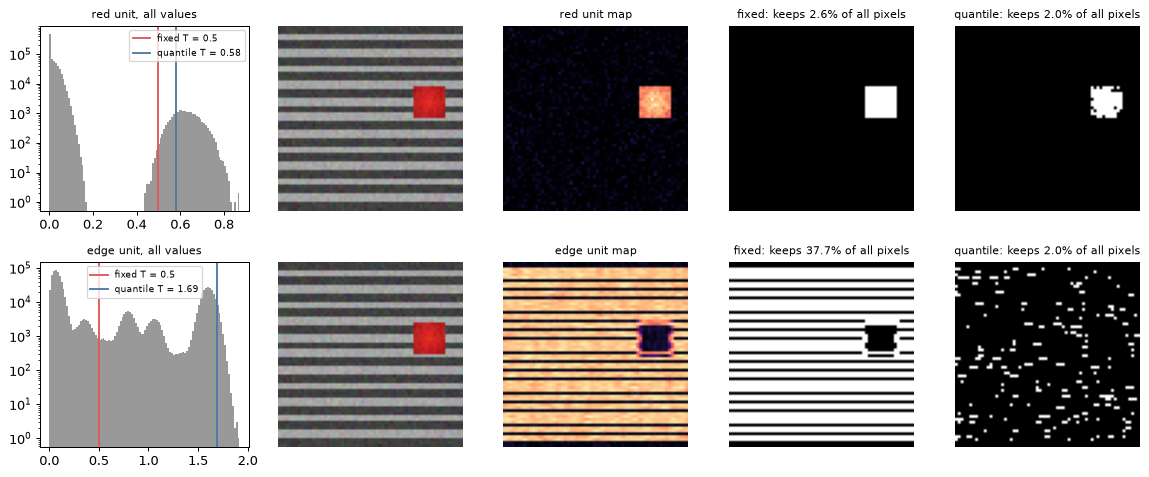

In [4]:
Q = 0.02
fixed = {n: 0.5 for n in units}
quant = {n: float(torch.quantile(a.flatten(), 1 - Q)) for n, a in units.items()}

has_red = red_mask.flatten(1).any(1)
edge_hits = (units["edge"] >= quant["edge"]).flatten(1).sum(1) * has_red
i = int(edge_hits.argmax())          # an image where both units keep some pixels
fig, axes = plt.subplots(2, 5, figsize=(13, 5.4))
for row, (name, a) in enumerate(units.items()):
    axes[row, 0].hist(a.flatten().numpy(), bins=100, log=True, color="#999")
    axes[row, 0].axvline(fixed[name], color="#e15759", label=f"fixed T = {fixed[name]}")
    axes[row, 0].axvline(quant[name], color="#4e79a7", label=f"quantile T = {quant[name]:.2f}")
    axes[row, 0].legend(fontsize=7)
    axes[row, 0].set_title(f"{name} unit, all values")
    axes[row, 1].imshow(images[i].permute(1, 2, 0))
    axes[row, 2].imshow(a[i], cmap="magma")
    for col, (label, t) in ((3, ("fixed", fixed[name])), (4, ("quantile", quant[name]))):
        sel = a >= t
        axes[row, col].imshow(sel[i], cmap="gray")
        axes[row, col].set_title(f"{label}: keeps {float(sel.float().mean()):.1%} of all pixels")
    axes[row, 2].set_title(f"{name} unit map")
for ax in axes[:, 1:].flat:
    ax.axis("off")
plt.tight_layout()
plt.show()

With one fixed number, the red unit keeps about 3% of all pixels and the louder edge unit almost 40%, so their masks are not comparable. With the quantile, both keep exactly 2%: the red unit keeps the core of its shape, the edge unit keeps its strongest edges. The comparison is then about *where* a unit fires, not *how loud* it is.

The quantile does not give the best mask for each unit taken alone. The red histogram has two clean humps, and 0.5 falls in the gap between them, so the fixed threshold keeps the whole square while the 2% quantile trims its border. What the quantile buys is fairness: every unit is judged on a mask of the same size, whatever its scale.

## Small vs large quantile

The quantile sets the size of the mask. Too large: the mask spills over the concept. Too small: the mask covers only the strongest part. For the red unit, two simple numbers per quantile:

* precision: share of selected pixels that are red
* recall: share of red pixels that are selected

red covers 2.6% of all pixels


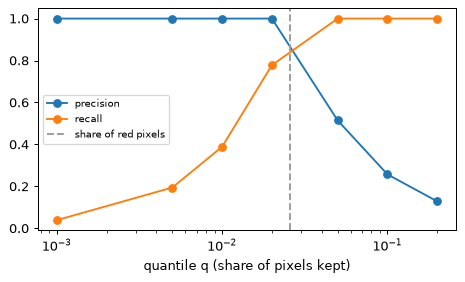

In [5]:
a = units["red"]
red_share = float(red_mask.float().mean())
print(f"red covers {red_share:.1%} of all pixels")
qs = [0.2, 0.1, 0.05, 0.02, 0.01, 0.005, 0.001]
rows = []
for q in qs:
    t = torch.quantile(a.flatten(), 1 - q)
    sel = a >= t
    inter = (sel & red_mask).sum().item()
    rows.append((q, inter / max(sel.sum().item(), 1), inter / red_mask.sum().item()))
prec, rec = np.array(rows)[:, 1], np.array(rows)[:, 2]

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(qs, prec, "o-", label="precision")
ax.plot(qs, rec, "o-", label="recall")
ax.axvline(red_share, color="#999", ls="--", label="share of red pixels")
ax.set_xscale("log")
ax.set_xlabel("quantile q (share of pixels kept)")
ax.legend(fontsize=8)
plt.show()

For a unit that separates the concept cleanly, like this one, precision and recall cross where q equals the share of the concept. A noisier unit would cross elsewhere, and never reach 1 on both.

The paper uses 0.005 on Broden without discussing the choice. A plausible reason is that most Broden concepts are small, so a unit is expected to fire rarely. On these toy scenes, where red covers 2.6% of all pixels, 0.02 fits better. The quantile is a design choice of the method, not a law.

## Computing the quantile at dataset scale

For one AlexNet conv1 unit on all of Broden there are about 200 million values. Sorting them for every unit is wasteful. Only the top $m = \lceil q \, n \rceil$ values matter, so a running `torch.topk` over batches gives the exact threshold: $T_k$ is the smallest kept value.

In [6]:
def streamed_threshold(batches, n_total, q):
    m = math.ceil(q * n_total)
    top = None
    for b in batches:
        v = b.flatten() if top is None else torch.cat([top, b.flatten()])
        top = v.topk(min(m, len(v)), sorted=False).values
    return top.min()


a = units["edge"]
t_stream = streamed_threshold(a.split(16), a.numel(), 0.005)
m = math.ceil(0.005 * a.numel())
t_sort = a.flatten().sort(descending=True).values[m - 1]
t_np = np.quantile(a.flatten().numpy(), 1 - 0.005)
print(f"streamed topk {float(t_stream):.5f}")
print(f"full sort     {float(t_sort):.5f}")
print(f"np.quantile   {t_np:.5f}  (may interpolate between two values)")
print(f"share above streamed T: {float((a > t_stream).float().mean()):.4%}")
assert t_stream == t_sort

streamed topk 1.72830
full sort     1.72830
np.quantile   1.72830  (may interpolate between two values)
share above streamed T: 0.4999%


## Same idea on a real unit

One unit of AlexNet conv5 (ImageNet weights) on 100 random ADE20K images from Broden. Its top 0.5% defines $T_k$. AlexNet's `features` is a plain sequence of layers, so slicing it up to the ReLU after conv5 gives the same maps as a hook on that ReLU (notebook 01). The masks are shown at the native 13 x 13 resolution of conv5: notebook 04 deals with bringing them to image size.

conv5 unit 150: 16900 values, T_k = 4.49, 94% of values are exactly 0 (ReLU)


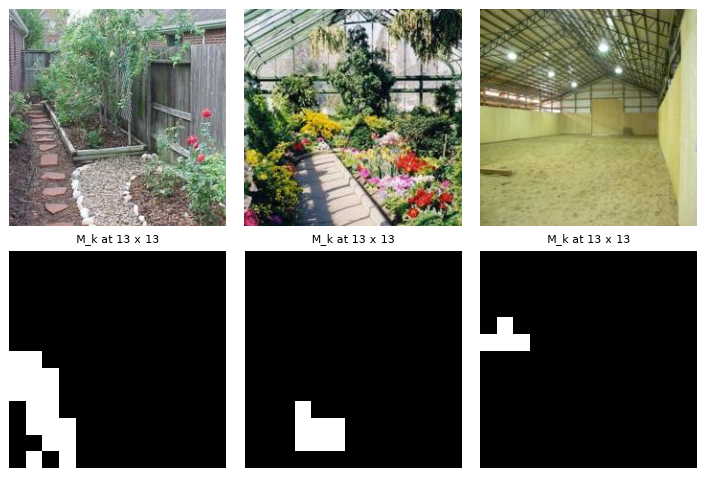

In [7]:
all_paths = sorted(Path("data/broden1_227/images/ade20k").glob("*.jpg"))
paths = [all_paths[j] for j in np.random.default_rng(0).choice(len(all_paths), 100, replace=False)]
x = torch.stack([TF.normalize(TF.to_tensor(Image.open(p).convert("RGB")), [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
                 for p in paths])
alexnet = models.alexnet(weights="IMAGENET1K_V1").eval()
with torch.no_grad():
    conv5 = alexnet.features[:12](x)
unit = 150
a = conv5[:, unit]
t = float(torch.quantile(a.flatten(), 1 - 0.005))
top = a.amax((1, 2)).argsort(descending=True)[:3]
print(f"conv5 unit {unit}: {a.numel()} values, T_k = {t:.2f}, {float((a == 0).float().mean()):.0%} of values are exactly 0 (ReLU)")

fig, axes = plt.subplots(2, 3, figsize=(8, 5.4))
for col, j in enumerate(top):
    axes[0, col].imshow(Image.open(paths[j]).convert("RGB"))
    axes[1, col].imshow((a[j] >= t).numpy(), cmap="gray", vmin=0, vmax=1)
    axes[1, col].set_title("M_k at 13 x 13")
for ax in axes.flat:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Takeaways

* A unit becomes a segmenter by thresholding its map: $M_k = A_k \geq T_k$.
* $T_k$ is a per unit quantile, so units with different scales are judged on masks of the same size.
* The quantile sets the mask size. The paper uses 0.005, larger values suit concepts that cover more of the image.
* The exact quantile over a huge dataset only needs a running top-k, not a full sort.

Next, notebook 04 brings low resolution maps such as conv5's 13 x 13 to the size of the concept masks.